In [ ]:
import torch
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
mefar_data = pd.read_csv('../Datasets/MEFAR_MID.csv')
mefar_data.head()

,BVP,EDA,TEMP,AccX,AccY,AccZ,HR,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,Attention,Meditation,class
0,-0.150426,0.026215,0.778824,-0.325490,0.019608,0.388235,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
1,-0.145506,0.026215,0.778824,-0.333333,-0.003922,0.388235,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
2,-0.135576,0.026215,0.778824,-0.349020,-0.035294,0.333333,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
3,-0.121047,0.026215,0.778824,-0.380392,-0.027451,0.356863,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
4,-0.103369,0.026215,0.778824,-0.411765,-0.011765,0.411765,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0


In [11]:
X = mefar_data.drop('class', axis = 1)
y = mefar_data['class']

low_impact_features = [
    ' Attention', ' Alpha1', ' Gamma2', ' Theta', ' Beta2',
    ' Delta', ' Meditation', ' Beta1', ' Gamma1', ' Alpha2'
]

X_reduced = X.drop(columns = low_impact_features)

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)


In [12]:
class dataset(Dataset):
    def __init__(self, x, y, scaler = None):
        
        if scaler is None:
            scaler = StandardScaler()
            x = scaler.fit_transform(x)

        else:
            x = scaler.transform(x)
            
        self.scaler = scaler
    
        
        x_np = np.array(x)
        y_np = np.array(y)

        self.x = torch.tensor(x_np, dtype = torch.float32)
        self.y = torch.tensor(y_np, dtype = torch.float32).unsqueeze(1)
        
        self.scaler = scaler

    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        x = self.x[idx]
        y = self.y[idx]

            
        return x, y

In [13]:
train_dataset = dataset(X_train, y_train, scaler = None)

scaler = train_dataset.scaler
test_dataset = dataset(X_test, y_test, scaler = scaler)

train_loader = DataLoader(train_dataset, batch_size = 200, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 200, shuffle = True)

val_loader = DataLoader(dataset(X_val, y_val, scaler = scaler), batch_size = 200, shuffle = True)

In [14]:
class NN(nn.Module):
    def __init__(self, input_dim = 7):
        super(NN, self).__init__()

        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.dropout2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(32, 1)


        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x
    
model= NN()
model.to(device)

NN(
  (fc1): Linear(in_features=7, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

In [16]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)  # Lower LR!
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

num_epochs = 100

Epoch [1/100] | Train Loss: 0.5759 | Train F1: 0.6707 | Val Loss: 0.4800 | Val F1: 0.7713
Epoch [10/100] | Train Loss: 0.3654 | Train F1: 0.8348 | Val Loss: 0.2804 | Val F1: 0.8799
Epoch [20/100] | Train Loss: 0.3255 | Train F1: 0.8558 | Val Loss: 0.2382 | Val F1: 0.9043
Epoch [30/100] | Train Loss: 0.3077 | Train F1: 0.8661 | Val Loss: 0.2146 | Val F1: 0.9178
Epoch [40/100] | Train Loss: 0.2990 | Train F1: 0.8703 | Val Loss: 0.2069 | Val F1: 0.9203
Epoch [50/100] | Train Loss: 0.2923 | Train F1: 0.8736 | Val Loss: 0.2020 | Val F1: 0.9265
Epoch [60/100] | Train Loss: 0.2886 | Train F1: 0.8761 | Val Loss: 0.1921 | Val F1: 0.9310
Epoch [70/100] | Train Loss: 0.2855 | Train F1: 0.8773 | Val Loss: 0.1882 | Val F1: 0.9318
Epoch [80/100] | Train Loss: 0.2847 | Train F1: 0.8780 | Val Loss: 0.1938 | Val F1: 0.9293
Epoch [90/100] | Train Loss: 0.2845 | Train F1: 0.8782 | Val Loss: 0.1859 | Val F1: 0.9359

✓ Early stopping at epoch 98

✓ Best model loaded (Val Loss: 0.1837)

TEST SET EVALUATION


Text(0.5, 80.7222222222222, 'Predicted')

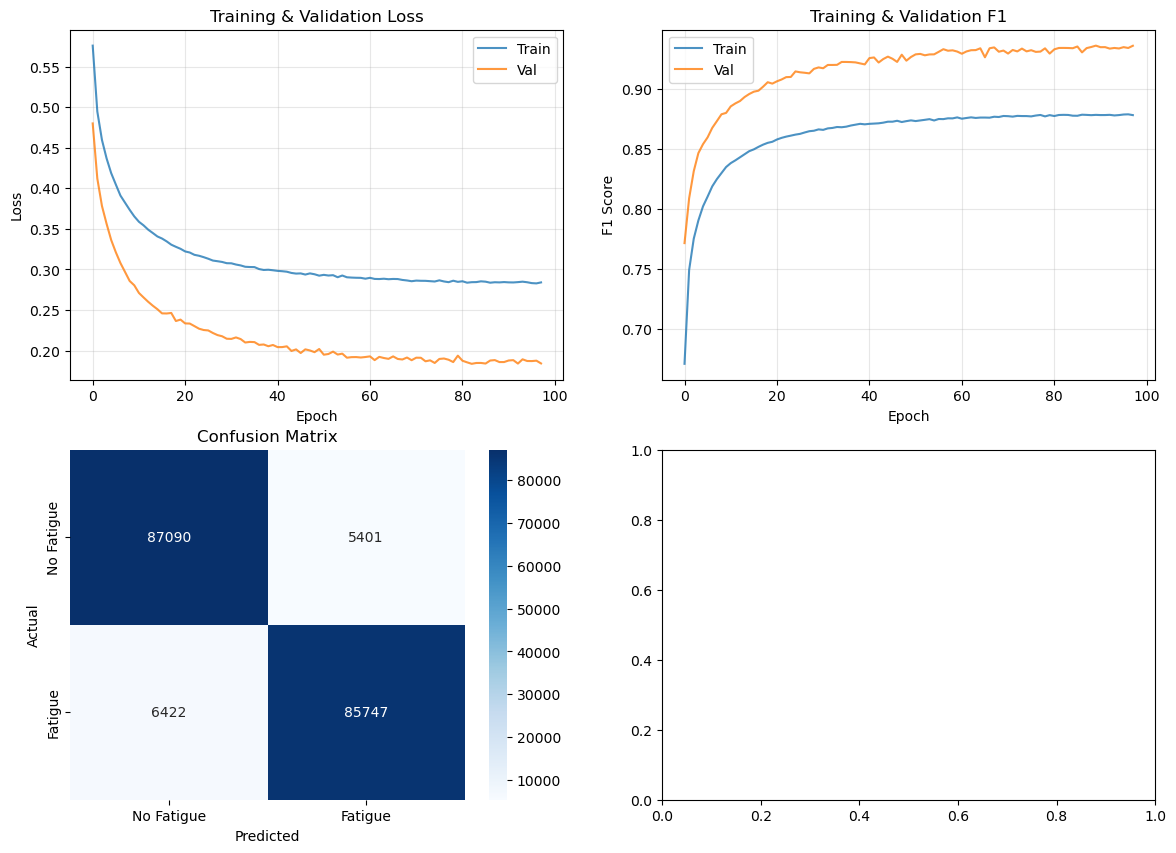

In [ ]:
train_losses = []
val_losses = []
train_f1_scores = []
val_f1_scores = []

best_val_loss = float('inf')
patience = 15
patience_counter = 0


for epoch in range(num_epochs):
    
    # Model Training
    model.train()
    train_loss = 0.0
    train_preds = []
    train_labels = []
    
    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        y_pred = model(X_batch)
        
        loss = loss_function(y_pred, y_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
        # Store predictions for F1
        with torch.no_grad():
            preds = (torch.sigmoid(y_pred) > 0.5).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(y_batch.cpu().numpy())
    
    train_loss /= len(train_loader)
    train_f1 = f1_score(train_labels, train_preds)
    train_losses.append(train_loss)
    train_f1_scores.append(train_f1)
    
#   Model Validation
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_pred = model(X_batch)
            loss = loss_function(y_pred, y_batch)
            
            val_loss += loss.item()
            
            preds = (torch.sigmoid(y_pred) > 0.5).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(y_batch.cpu().numpy())
    
    val_loss /= len(val_loader)
    val_f1 = f1_score(val_labels, val_preds)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}] | '
              f'Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}')
    
    # Early stopping check
    if patience_counter >= patience:
        print(f'\n Early stopping at epoch {epoch+1}')
        break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
print(f"\n✓ Best model loaded (Val Loss: {best_val_loss:.4f})")

# Test Set Evaluation

model.eval()
test_preds = []
test_probs = []
test_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        
        y_pred = model(X_batch)
        probs = torch.sigmoid(y_pred).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        
        test_preds.extend(preds)
        test_probs.extend(probs)
        test_labels.extend(y_batch.numpy())

test_preds = np.array(test_preds).flatten()
test_probs = np.array(test_probs).flatten()
test_labels = np.array(test_labels).flatten()

test_f1 = f1_score(test_labels, test_preds)

print(f"\nTest F1 Score: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, 
                          target_names=['No Fatigue', 'Fatigue']))

cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Model Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
axes[0, 0].plot(train_losses, label='Train', alpha=0.8)
axes[0, 0].plot(val_losses, label='Val', alpha=0.8)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# F1 curves
axes[0, 1].plot(train_f1_scores, label='Train', alpha=0.8)
axes[0, 1].plot(val_f1_scores, label='Val', alpha=0.8)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_title('Training & Validation F1')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['No Fatigue', 'Fatigue'],
            yticklabels=['No Fatigue', 'Fatigue'])
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_xlabel('Predicted')

In [ ]:
plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"Final Test F1: {test_f1:.4f}")
print(f"Model saved: best_model.pth")
print(f"Plot saved: training_results.png")

<Figure size 640x480 with 0 Axes>


✓ TRAINING COMPLETE!
Final Test F1: 0.9355
Model saved: best_model.pth
Plot saved: training_results.png
